<a href="https://colab.research.google.com/github/sandya-1210/Predictive_Analytics/blob/main/heart_disease_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

heart_df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data',
    names=column_names, na_values='?'
)

heart_df.to_csv('heart.csv', index=False)

print("heart.csv created successfully!")

heart.csv created successfully!


    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Shape: (297, 14)

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target Distribution:
 target
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64


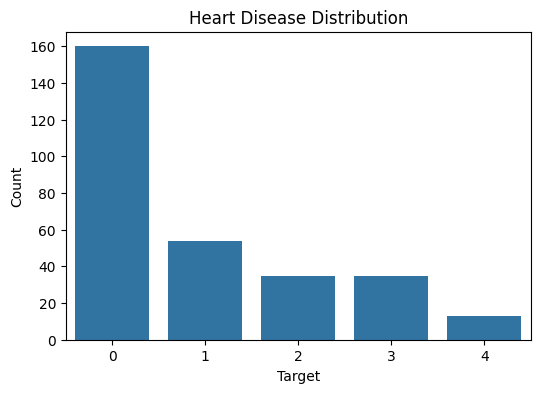

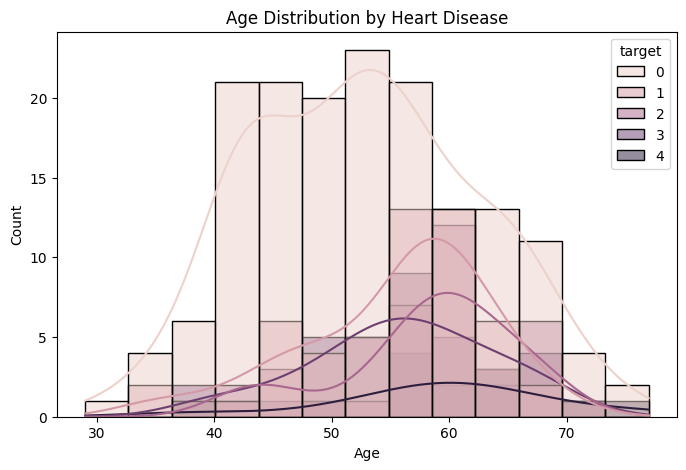

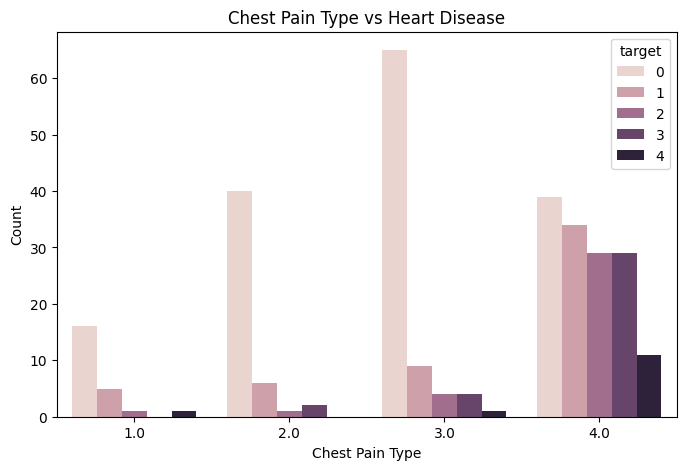

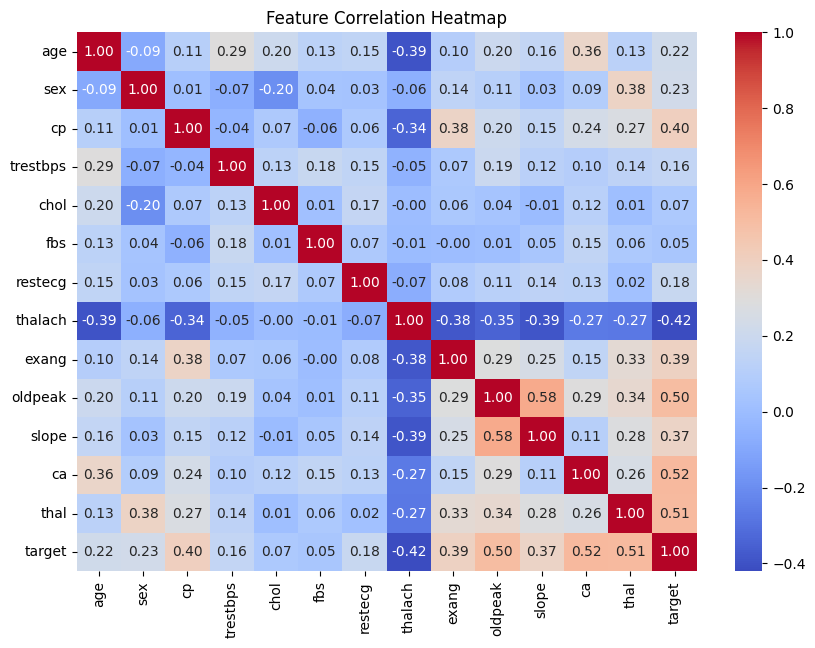


 Logistic Regression
Accuracy: 0.6
              precision    recall  f1-score   support

           0       0.79      0.94      0.86        32
           1       0.50      0.27      0.35        11
           2       0.00      0.00      0.00         7
           3       0.33      0.43      0.38         7
           4       0.00      0.00      0.00         3

    accuracy                           0.60        60
   macro avg       0.32      0.33      0.32        60
weighted avg       0.55      0.60      0.57        60


 Decision Tree
Accuracy: 0.48333333333333334
              precision    recall  f1-score   support

           0       0.88      0.69      0.77        32
           1       0.28      0.45      0.34        11
           2       0.14      0.14      0.14         7
           3       0.10      0.14      0.12         7
           4       0.00      0.00      0.00         3

    accuracy                           0.48        60
   macro avg       0.28      0.29      0.28      

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 Random Forest
Accuracy: 0.5666666666666667
              precision    recall  f1-score   support

           0       0.78      0.97      0.86        32
           1       0.11      0.09      0.10        11
           2       0.25      0.14      0.18         7
           3       0.17      0.14      0.15         7
           4       0.00      0.00      0.00         3

    accuracy                           0.57        60
   macro avg       0.26      0.27      0.26        60
weighted avg       0.48      0.57      0.52        60


 KNN
Accuracy: 0.5833333333333334
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        32
           1       0.25      0.27      0.26        11
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00         3

    accuracy                           0.58        60
   macro avg       0.21      0.25      0.23        

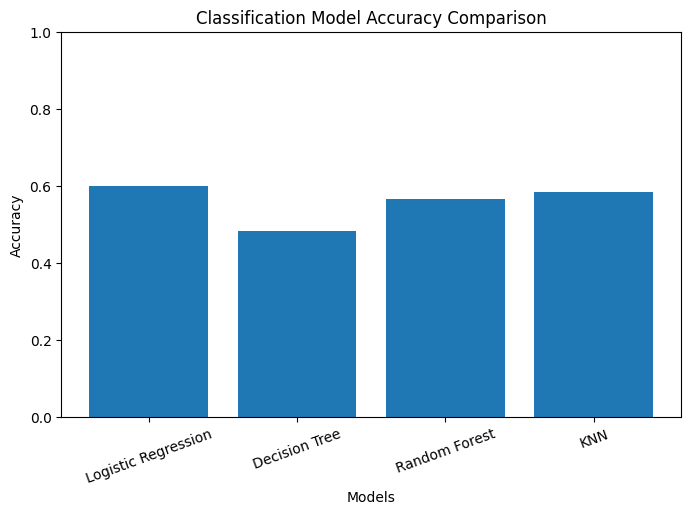


Model Accuracies:
Logistic Regression : 60.0 %
Decision Tree : 48.33 %
Random Forest : 56.67 %
KNN : 58.33 %

Highest Accuracy Model: Logistic Regression


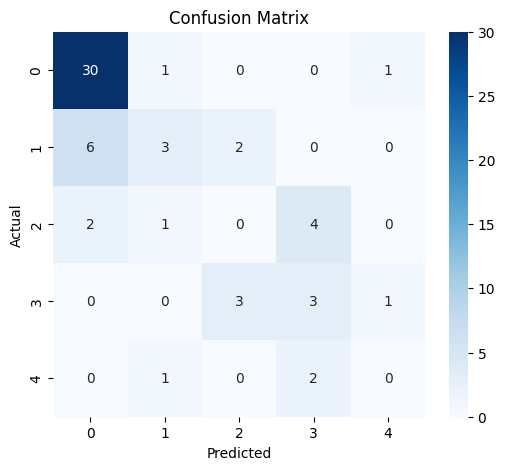

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("heart.csv")

df.dropna(inplace=True)

print(df.head())
print("\nShape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df["target"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="target", kde=True)
plt.title("Age Distribution by Heart Disease")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x="cp", hue="target", data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    if name == "Logistic Regression" or name == "KNN":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print("\n", name)
    print("Accuracy:", accuracy)
    print(classification_report(y_test, y_pred))

best_model = max(results, key=results.get)

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("Classification Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.show()

print("\nModel Accuracies:")
for model, accuracy in results.items():
    print(model, ":", round(accuracy * 100, 2), "%")

print("\nHighest Accuracy Model:", best_model)

if best_model == "Logistic Regression" or best_model == "KNN":
    final_model = models[best_model]
    final_model.fit(X_train_scaled, y_train)
    final_pred = final_model.predict(X_test_scaled)
else:
    final_model = models[best_model]
    final_model.fit(X_train, y_train)
    final_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()